# Vanilla PINN —— Setting B (Wang–He–Wylie–Huang, 2:−1)

$$\varepsilon^2\phi''=-(2c_1-c_2),\qquad c_1'+2c_1\phi'=-J_1,\qquad c_2'-c_2\phi'=-J_2$$

| | |
|---|---|
| 离子 | $n=2$, $\alpha_1=2$, $\alpha_2=-1$ —— Ca²⁺ : Cl⁻ |
| 通道 | $h\equiv1$,  永久电荷 $Q\equiv0$ |
| 电中性 | 外区域 $2c_1=c_2$;  电流 $I=2J_1-J_2$ |
| 边界条件 | $V=1$, $L_1=1.0$, $L_2=1.5$, $R_1=2.5$, $R_2=1.0$ |
| 摄动参数 | $\varepsilon=10^{-2}$ |
| 训练步数 | $3\times10^5$ (分段: $5\times10^4+5\times10^4+2\times10^5$) |

非对称价数使外解非退化 ($c_{10}\neq c_{20}$), 内系统的首次积分结构改变,
匹配过程需解三次方程。参考解由 `scipy.integrate.solve_bvp` 求解完整 PNP 系统给出。


## 1. 导入库和设置


In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad as torch_grad
from scipy.integrate import solve_bvp as scipy_bvp, trapezoid

# 自动选择计算设备
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {DEVICE}")

# Matplotlib配置
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16

使用设备: cuda


## 2. 边界条件与辅助函数


In [2]:
def create_boundary_conditions(V, L1, L2, R1, R2):

    return {
        'V': V,      # 施加电压
        'L1': L1,    # 左边界离子1(正离子)浓度
        'L2': L2,    # 左边界离子2(负离子)浓度
        'R1': R1,    # 右边界离子1浓度
        'R2': R2     # 右边界离子2浓度
    }


def is_electroneutral(bc):
    """检查是否满足电中性条件"""
    return (abs(2*bc['L1'] - bc['L2']) < 1e-10 and 
        abs(2*bc['R1'] - bc['R2']) < 1e-10)


def bc_to_string(bc):
    """边界条件的字符串表示"""
    status = "电中性" if is_electroneutral(bc) else "非电中性"
    return (f"BoundaryConditions(V={bc['V']}, "
            f"Left=[{bc['L1']}, {bc['L2']}], "
            f"Right=[{bc['R1']}, {bc['R2']}]) [{status}]")

## 3. Vanilla PINN 模型


In [3]:
class PINN_PNP(nn.Module):
    """普通 PINN: 简单全连接网络直接求解完整 PNP 系统"""
    def __init__(self, layers=[1, 112, 112, 112, 112, 3]):
        super(PINN_PNP, self).__init__()
        self.linears = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
        self.activation = nn.Tanh()

    def forward(self, x):
        u = x
        for i, lin in enumerate(self.linears[:-1]):
            u = self.activation(lin(u))
        u = self.linears[-1](u)
        c1 = u[:, 0:1]
        c2 = u[:, 1:2]
        phi = u[:, 2:3]
        return c1, c2, phi

## 4. 损失函数


In [4]:
def compute_loss(model, epsilon, V, L1, L2, R1, R2, device):
    """
    普通 PINN 损失函数: 直接在完整 PNP 系统上施加 PDE 残差和边界条件
    
    PDE 系统 (h=1, Q=0, α₁=1, α₂=−1):
      ε² φ'' = -(c₁ - c₂)          Poisson 方程
      d/dx(c₁' + c₁ φ') = 0         Nernst-Planck (离子1)
      d/dx(c₂' - c₂ φ') = 0         Nernst-Planck (离子2)
    """
    losses = {}
    
    # ---------- 内部配点 ----------
    N_in = 500
    x_in = torch.rand(N_in, 1, device=device, requires_grad=True)
    
    c1_pred, c2_pred, phi_pred = model(x_in)
    
    # 一阶导数
    grad_phi = torch_grad(phi_pred, x_in, grad_outputs=torch.ones_like(phi_pred),
                          create_graph=True)[0]
    grad_c1 = torch_grad(c1_pred, x_in, grad_outputs=torch.ones_like(c1_pred),
                         create_graph=True)[0]
    grad_c2 = torch_grad(c2_pred, x_in, grad_outputs=torch.ones_like(c2_pred),
                         create_graph=True)[0]
    # 二阶导数
    grad2_phi = torch_grad(grad_phi, x_in, grad_outputs=torch.ones_like(grad_phi),
                           create_graph=True)[0]
    
    # Poisson 方程残差: ε² φ'' + (c₁ - c₂) = 0
    residual_poisson = epsilon**2 * grad2_phi + (2*c1_pred - c2_pred)
    loss_p = torch.mean(residual_poisson**2)
    losses['p'] = loss_p
    
    # Nernst-Planck 方程: 通量 J₁ = c₁' + c₁ φ' 应为常数, J₂ = c₂' - c₂ φ' 应为常数
    # 等价于对 J 求导为零
    flux1 = grad_c1 + 2*c1_pred * grad_phi
    flux2 = grad_c2 - c2_pred * grad_phi
    grad_flux1 = torch_grad(flux1, x_in, grad_outputs=torch.ones_like(flux1),
                            create_graph=True)[0]
    grad_flux2 = torch_grad(flux2, x_in, grad_outputs=torch.ones_like(flux2),
                            create_graph=True)[0]
    loss_np1 = torch.mean(grad_flux1**2)
    loss_np2 = torch.mean(grad_flux2**2)
    losses['np1'] = loss_np1
    losses['np2'] = loss_np2
    
    # ---------- 边界条件 ----------
    x_left = torch.zeros(1, 1, device=device)
    x_right = torch.ones(1, 1, device=device)
    
    c1_L, c2_L, phi_L = model(x_left)
    c1_R, c2_R, phi_R = model(x_right)
    
    loss_bc = ((phi_L - V)**2 + (c1_L - L1)**2 + (c2_L - L2)**2 +
               phi_R**2 + (c1_R - R1)**2 + (c2_R - R2)**2).mean()
    losses['bc'] = loss_bc
    
    # ---------- 总损失 ----------
    total = 1.0 * loss_p + 1.0 * loss_np1 + 1.0 * loss_np2 + 50.0 * loss_bc
    losses['total'] = total
    
    return total, losses

## 5. 训练函数


In [5]:
def train_pinn(model, epsilon, V, L1, L2, R1, R2, device, epochs=150000, log_interval=500):
    """
    训练普通 PINN 模型
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, epochs, eta_min=1e-6
    )
    
    history = {'loss': []}
    best_loss = float('inf')
    best_state = None
    
    for ep in range(epochs):
        optimizer.zero_grad()
        loss, details = compute_loss(model, epsilon, V, L1, L2, R1, R2, device)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        scheduler.step()
        
        if loss.item() < best_loss:
            best_loss = loss.item()
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        
        history['loss'].append(loss.item())
        
        if (ep + 1) % log_interval == 0:
            print(f"Epoch {ep+1:6d}/{epochs} | Loss: {loss.item():.4e} | "
                  f"P: {details['p'].item():.2e} | NP1: {details['np1'].item():.2e} | "
                  f"NP2: {details['np2'].item():.2e} | BC: {details['bc'].item():.2e}")
    
    # 恢复最佳模型
    if best_state is not None:
        model.load_state_dict(best_state)
    
    print(f'训练完成! 最佳损失: {best_loss:.4e}')
    return history

## 6. 问题设置与单次训练


In [6]:
# 物理参数设置
eps = 1e-2   # Debye长度参数
V = 1.0       # 施加电压

# 边界浓度 (非电中性情形, 2:-1 价态)
L1 = 1.0      # 左边界 z1=+2 离子浓度
L2 = 1.5      # 左边界 z2=-1 离子浓度
R1 = 2.5      # 右边界 z1=+2 离子浓度
R2 = 1.0      # 右边界 z2=-1 离子浓度

print('  Vanilla PINN for PNP System')
print(f"  ε = {eps},  V = {V}")
print(f"  Left BC:  L1 = {L1}, L2 = {L2}")
print(f"  Right BC: R1 = {R1}, R2 = {R2}")

# 4 个隐藏层, 宽度 112, 参数量 38531 ≈ PVD-Net 的 38346
epochs = 300000

model = PINN_PNP(layers=[1, 96, 96, 96, 96,96,3]).to(DEVICE)

param_count = sum(p.numel() for p in model.parameters())
print(f"\n模型参数量: {param_count:,}")
print(model)

import time

start_time = time.time()
# 训练模型
history = train_pinn(model, eps, V, L1, L2, R1, R2, DEVICE, epochs=epochs, log_interval=500)
end_time = time.time() # 记录结束时间

print(f"程序运行时间：{end_time - start_time} 秒")

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import FormatStrFormatter

  Vanilla PINN for PNP System
  ε = 0.01,  V = 1.0
  Left BC:  L1 = 1.0, L2 = 1.5
  Right BC: R1 = 2.5, R2 = 1.0

模型参数量: 37,731
PINN_PNP(
  (linears): ModuleList(
    (0): Linear(in_features=1, out_features=96, bias=True)
    (1-4): 4 x Linear(in_features=96, out_features=96, bias=True)
    (5): Linear(in_features=96, out_features=3, bias=True)
  )
  (activation): Tanh()
)
Epoch    500/300000 | Loss: 1.1111e+00 | P: 7.77e-01 | NP1: 2.45e-01 | NP2: 1.82e-02 | BC: 1.43e-03
Epoch   1000/300000 | Loss: 1.7855e+00 | P: 8.46e-01 | NP1: 3.28e-01 | NP2: 1.20e-02 | BC: 1.20e-02
Epoch   1500/300000 | Loss: 1.1859e+00 | P: 6.84e-01 | NP1: 2.26e-01 | NP2: 1.20e-02 | BC: 5.28e-03
Epoch   2000/300000 | Loss: 1.2120e+00 | P: 1.08e+00 | NP1: 1.08e-01 | NP2: 7.86e-03 | BC: 2.81e-04
Epoch   2500/300000 | Loss: 1.5935e+00 | P: 9.39e-01 | NP1: 5.94e-01 | NP2: 2.27e-02 | BC: 7.47e-04
Epoch   3000/300000 | Loss: 8.6974e-01 | P: 6.77e-01 | NP1: 1.68e-01 | NP2: 1.77e-02 | BC: 1.54e-04
Epoch   3500/300000 | Lo

## 7. 精确参考解


In [7]:
def compute_exact_reference(eps, V, L1, L2, R1, R2, n_init=5000):
    # ---- 2:-1 零阶解析公式用于初始猜测 ----
    c_L = (L1 * L2**2 / 4.0) ** (1.0/3.0)
    c_R = (R1 * R2**2 / 4.0) ** (1.0/3.0)
    phi_L = V - np.log(L2 / (2.0*L1)) / 3.0
    phi_R = np.log(2.0*R1 / R2) / 3.0

    T0 = 3.0 * (c_L - c_R)
    if abs(T0) > 1e-12:
        I0 = 2.0 * T0 * (phi_R - phi_L) / np.log(c_R / c_L)
    else:
        I0 = 6.0 * c_L * (phi_R - phi_L)
    J10 = (I0 + T0) / 3.0
    J20 = (2.0*T0 - I0) / 3.0

    x_init = np.linspace(0, 1, n_init)
    c0 = c_L - T0 * x_init / 3.0
    M = 3.0 * c_L
    if abs(T0) > 1e-12:
        phi0 = phi_L - (I0/(2.0*T0))*np.log(M) + (I0/(2.0*T0))*np.log(np.abs(M - T0*x_init))
    else:
        phi0 = phi_L + I0 * x_init / (6.0*c_L)

    xi = x_init / eps
    bl_L = np.exp(-np.sqrt(3.0*c_L) * np.minimum(xi, 100))
    eta = (x_init - 1.0) / eps
    bl_R = np.exp(np.sqrt(3.0*c_R) * np.maximum(eta, -100))

    delta_L = V - phi_L
    delta_R = -phi_R
    phi_guess = phi0 + delta_L * bl_L + delta_R * bl_R
    c1_guess = np.maximum(c0 * np.exp(-2.0*delta_L*bl_L) * np.exp(-2.0*delta_R*bl_R), 0.01)
    c2_guess = np.maximum(2.0*c0 * np.exp(delta_L*bl_L) * np.exp(delta_R*bl_R), 0.01)

    y0 = np.zeros((6, n_init))
    y0[0] = phi_guess
    y0[1] = np.gradient(phi_guess, x_init)
    y0[2] = c1_guess
    y0[3] = c2_guess
    y0[4] = J10
    y0[5] = J20

    def pnp_ode(x, y):
        phi, E, c1, c2, J1, J2 = y
        return np.vstack([
            E,
            -(2.0*c1 - c2) / eps**2,    # ★ 2:-1 Poisson
            -2.0*c1*E - J1,              # ★ z1=2 NP
            c2*E - J2,                    #   z2=-1 NP
            np.zeros_like(x),
            np.zeros_like(x)
        ])

    def pnp_bc(ya, yb):
        return np.array([ya[0]-V, yb[0], ya[2]-L1, yb[2]-R1, ya[3]-L2, yb[3]-R2])

    sol = scipy_bvp(pnp_ode, pnp_bc, x_init, y0, tol=1e-8, max_nodes=100000)
    assert sol.success, f'精确解求解失败: {sol.message}'
    return sol

## 8. 统一评估网格与误差指标


In [8]:
def create_evaluation_grid(eps, n_inner_per_side=2500, n_outer=200):
    """按论文方式创建分区评估网格"""
    bl_w = min(10 * eps, 0.05)  # 边界层宽度
    
    # 左边界层: [0, bl_w] 密集采点
    x_left_bl = np.linspace(0, bl_w, n_inner_per_side, endpoint=False)
    
    # 右边界层: [1-bl_w, 1] 密集采点
    x_right_bl = np.linspace(1 - bl_w, 1, n_inner_per_side, endpoint=True)
    
    # 交界点
    x_junction = np.array([bl_w, 1 - bl_w])
    
    # 外区域: (bl_w, 1-bl_w) 均匀采点
    x_outer = np.linspace(bl_w, 1 - bl_w, n_outer + 2)[1:-1]  # 去掉端点避免重复
    
    # 合并并排序
    x_all = np.sort(np.unique(np.concatenate([x_left_bl, x_right_bl, x_junction, x_outer])))
    
    # 记录各区域的索引掩码
    return {
        'x': x_all,
        'n': len(x_all),
        'bl_width': bl_w,
        'eps': eps,
        'mask_left_bl': x_all <= bl_w,
        'mask_right_bl': x_all >= 1 - bl_w,
        'mask_inner': (x_all <= bl_w) | (x_all >= 1 - bl_w),       # 所有边界层点
        'mask_outer': (x_all > bl_w) & (x_all < 1 - bl_w),          # 外区域
        'junction_left': np.argmin(np.abs(x_all - bl_w)),            # 左交界点索引
        'junction_right': np.argmin(np.abs(x_all - (1 - bl_w))),     # 右交界点索引
    }


def compute_unified_metrics(phi_a, c1_a, c2_a, J1_a, J2_a,
                            phi_e, c1_e, c2_e, J1_e, J2_e, grids):
    """
    按论文 Table 2 的五项指标评估:
    ① 全局相对 L²   ② 全局 L∞
    ③ 内区域相对 L²  ④ 内区域 L∞
    ⑤ 交界点误差
    """
    x = grids['x']
    mask_inner = grids['mask_inner']
    mask_left_bl = grids['mask_left_bl']
    mask_right_bl = grids['mask_right_bl']
    jL = grids['junction_left']
    jR = grids['junction_right']
    
    results = {}
    for name, ua, ue in [('phi', phi_a, phi_e), ('c1', c1_a, c1_e), ('c2', c2_a, c2_e)]:
        err = np.abs(ua - ue)
        
        # ① 全局相对 L²
        norm_e = np.sqrt(trapezoid(ue**2, x))
        norm_err = np.sqrt(trapezoid(err**2, x))
        global_rel_L2 = norm_err / max(norm_e, 1e-16)
        
        # ② 全局 L∞
        global_Linf = np.max(err)
        
        # ③ 内区域（边界层）相对 L²
        # 左右两段是不相连的区间，必须分别积分后相加。若直接对拼接后的节点
        # 数组调用 trapezoid，会在 w_BL 与 1-w_BL 之间多出一段宽度
        # (1-2*w_BL) 的伪梯形，分子分母同时被污染。
        def _int_sq(v, m):
            return trapezoid(v[m]**2, x[m]) if np.count_nonzero(m) > 1 else 0.0
        den_sq = _int_sq(ue, mask_left_bl) + _int_sq(ue, mask_right_bl)
        num_sq = _int_sq(err, mask_left_bl) + _int_sq(err, mask_right_bl)
        if den_sq > 0.0:
            inner_rel_L2 = np.sqrt(num_sq) / max(np.sqrt(den_sq), 1e-16)
        else:
            inner_rel_L2 = np.nan
        
        # ④ 内区域 L∞
        inner_Linf = np.max(err[mask_inner]) if np.any(mask_inner) else np.nan
        
        # ⑤ 交界点误差 (取左右交界点的最大误差)
        junction_err = max(err[jL], err[jR])
        
        results[name] = {
            'global_rel_L2': global_rel_L2,
            'global_Linf': global_Linf,
            'inner_rel_L2': inner_rel_L2,
            'inner_Linf': inner_Linf,
            'junction_err': junction_err,
        }
    
    # 通量和电流指标保持不变
    results['flux'] = {
        'J1_rel_err': abs(J1_a - J1_e) / max(abs(J1_e), 1e-16),
        'J2_rel_err': abs(J2_a - J2_e) / max(abs(J2_e), 1e-16),
    }
    I_a, I_e = 2.0*J1_a - J2_a, 2.0*J1_e - J2_e   # ★ 2:-1 价数
    results['current'] = {
        'I_rel_err': abs(I_a - I_e) / max(abs(I_e), 1e-16),
        'I_approx': I_a, 'I_exact': I_e,
    }
    return results


def print_unified_table(metrics, method_name, eps):
    print(f'  统一评估: {method_name}  (ε = {eps})')
    print(f'  参考解: 完整 PNP 系统 scipy BVP 精确数值解')
    print(f"  {'指标':<22s} | {'phi':>12s} | {'c1':>12s} | {'c2':>12s}")
    print(f"  {'-'*22}-+-{'-'*12}-+-{'-'*12}-+-{'-'*12}")
    for mk, ml in [('global_rel_L2', '① 全局相对 L²'),
                    ('global_Linf',   '② 全局 L∞'),
                    ('inner_rel_L2',  '③ 内区域相对 L²'),
                    ('inner_Linf',    '④ 内区域 L∞'),
                    ('junction_err',  '⑤ 交界点误差')]:
        vals = [metrics[v][mk] for v in ['phi', 'c1', 'c2']]
        print(f"  {ml:<22s} | {vals[0]:>12.4e} | {vals[1]:>12.4e} | {vals[2]:>12.4e}")
    print(f"  {'-'*22}-+-{'-'*12}-+-{'-'*12}-+-{'-'*12}")
    print(f"\n  I_approx = {metrics['current']['I_approx']:.6f},  I_exact = {metrics['current']['I_exact']:.6f}")

def plot_vs_exact(x, phi_nn, c1_nn, c2_nn, phi_ex, c1_ex, c2_ex, eps, method_name):
    """统一绘图: NN解 vs 精确解 (3×2)"""
    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    fig.suptitle(f'{method_name}  vs  Exact BVP  (ε={eps})', fontsize=14, fontweight='bold')

    # [0,0] 电势
    ax = axes[0,0]
    ax.plot(x, phi_ex, 'k-', lw=2.5, alpha=0.5, label='Exact BVP')
    ax.plot(x, phi_nn, 'r--', lw=2, label=method_name)
    ax.set(xlabel='x', ylabel='φ', title='Electric Potential'); ax.legend(); ax.grid(alpha=0.3)

    # [0,1] 浓度
    ax = axes[0,1]
    ax.plot(x, c1_ex, 'k-', lw=2.5, alpha=0.5, label='$c_1$ Exact')
    ax.plot(x, c2_ex, 'k:', lw=2.5, alpha=0.5, label='$c_2$ Exact')
    ax.plot(x, c1_nn, 'r--', lw=2, label='$c_1$ NN')
    ax.plot(x, c2_nn, 'm--', lw=2, label='$c_2$ NN')
    ax.set(xlabel='x', ylabel='c', title='Concentrations'); ax.legend(); ax.grid(alpha=0.3)

    # [1,0] 左边界层
    ax = axes[1,0]; mask = x < 0.02
    ax.plot(x[mask], c1_ex[mask], 'k-', lw=3, label='$c_1$ Exact')
    ax.plot(x[mask], c2_ex[mask], 'k:', lw=3, label='$c_2$ Exact')
    ax.plot(x[mask], c1_nn[mask], 'r--', lw=2, label='$c_1$ NN')
    ax.plot(x[mask], c2_nn[mask], 'm--', lw=2, label='$c_2$ NN')
    ax.set(xlabel='x', title='Left BL (x<0.02)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # [1,1] 右边界层
    ax = axes[1,1]; mask = x > 0.98
    ax.plot(x[mask], c1_ex[mask], 'k-', lw=3, label='$c_1$ Exact')
    ax.plot(x[mask], c2_ex[mask], 'k:', lw=3, label='$c_2$ Exact')
    ax.plot(x[mask], c1_nn[mask], 'r--', lw=2, label='$c_1$ NN')
    ax.plot(x[mask], c2_nn[mask], 'm--', lw=2, label='$c_2$ NN')
    ax.set(xlabel='x', title='Right BL (x>0.98)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # [2,0] 逐点误差
    ax = axes[2,0]
    for var, u_nn, u_ex, c in [('φ', phi_nn, phi_ex, 'b'), ('c₁', c1_nn, c1_ex, 'r'), ('c₂', c2_nn, c2_ex, 'g')]:
        ax.semilogy(x, np.abs(u_nn - u_ex)+1e-16, c+'-', lw=1.5, label=var)
    ax.axhline(eps, color='gray', ls='--', alpha=0.5, label=f'ε={eps}')
    ax.axhline(eps**2, color='gray', ls=':', alpha=0.5, label=f'ε²={eps**2}')
    ax.set(xlabel='x', ylabel='|error|', title='Pointwise Error vs Exact BVP')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # [2,1] 指标说明
    ax = axes[2,1]
    ax.text(0.5, 0.5, f'{method_name}\nThe unified evaluation indicators are shown in the table above.',
            ha='center', va='center', fontsize=14, transform=ax.transAxes)
    ax.axis('off')

    plt.tight_layout()
    plt.show()
    return fig

## 9. 单次评估


In [9]:
# 单次评估: 使用第 7 节训练好的 model
print('求解精确参考解 ...')
sol_exact = compute_exact_reference(eps, V, L1, L2, R1, R2)
grids = create_evaluation_grid(eps)
x_eval = grids['x']
y_ex = sol_exact.sol(x_eval)
phi_ex, c1_ex, c2_ex = y_ex[0], y_ex[2], y_ex[3]
J1_ex, J2_ex = y_ex[4, 0], y_ex[5, 0]
print(f'精确解通量: J1={J1_ex:.6f}, J2={J2_ex:.6f}, I=2J1-J2={2*J1_ex-J2_ex:.6f}')

model_i = model
x_t = torch.tensor(x_eval.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
model_i.eval()
with torch.no_grad():
    c1_t, c2_t, phi_t = model_i(x_t)
phi_nn = phi_t.cpu().numpy().flatten()
c1_nn = c1_t.cpu().numpy().flatten()
c2_nn = c2_t.cpu().numpy().flatten()
dphi_dx = np.gradient(phi_nn, x_eval)
J1_nn = np.median(-(np.gradient(c1_nn, x_eval) + 2.0*c1_nn*dphi_dx))
J2_nn = np.median(-(np.gradient(c2_nn, x_eval) - c2_nn*dphi_dx))
print(f'NN 通量:     J1={J1_nn:.6f}, J2={J2_nn:.6f}, I=2J1-J2={2*J1_nn-J2_nn:.6f}')

metrics = compute_unified_metrics(
    phi_nn, c1_nn, c2_nn, J1_nn, J2_nn,
    phi_ex, c1_ex, c2_ex, J1_ex, J2_ex, grids)
print_unified_table(metrics, 'Vanilla PINN', eps)

求解精确参考解 ...
精确解通量: J1=0.913601, J2=-0.995137, I=2J1-J2=2.822339
NN 通量:     J1=0.918665, J2=-0.990588, I=2J1-J2=2.827917
  统一评估: Vanilla PINN  (ε = 0.01)
  参考解: 完整 PNP 系统 scipy BVP 精确数值解
  指标                     |          phi |           c1 |           c2
  -----------------------+--------------+--------------+-------------
  ① 全局相对 L²              |   3.4203e-02 |   8.4177e-02 |   2.4661e-02
  ② 全局 L∞                |   2.3911e-01 |   7.0316e-01 |   3.2858e-01
  ③ 内区域相对 L²             |   1.0327e-01 |   2.4241e-01 |   7.6370e-02
  ④ 内区域 L∞               |   2.3911e-01 |   7.0316e-01 |   3.2858e-01
  ⑤ 交界点误差                |   3.5164e-02 |   6.1634e-02 |   5.7840e-02
  -----------------------+--------------+--------------+-------------

  I_approx = 2.827917,  I_exact = 2.822339


## 10. 可视化


In [ ]:
"""
plot_inset.py  —  带边界层放大嵌入图的可视化函数
替换原 notebook 中的 plot_vs_exact，将 c₁/c₂ 和边界层放大图合到同一张图中。
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import FormatStrFormatter

# ============================================================
# Plot style: Computer Modern font, matching TikZ diagram
# ============================================================
plt.rcParams.update({
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.serif': ['cmr10', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'axes.formatter.use_mathtext': True,
    'legend.fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.framealpha': 1.0,
    'legend.edgecolor': '0.7',
    'legend.fancybox': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# ============================================================
# Colors matching the TikZ diagram palette
# ============================================================
BLUE    = '#1a56db'   # reference / c1 exact
RED     = '#c0392b'   # NN / c1 NN
GREEN   = '#00a050'   # c2 exact (or error φ)
PURPLE  = '#8c3cb4'   # c2 NN
ORANGE  = '#e67e22'   # error c2
BLUE_D  = '#0b2e7a'   # darker blue variant
GREEN_D = '#005c2e'   # darker green variant


def plot_with_inset(x, phi_nn, c1_nn, c2_nn, phi_ex, c1_ex, c2_ex,
                    eps, method_name,
                    bl_left=0.01, bl_right=0.990,
                    save_path=None):
    """
    生成两张图:
      图1: 电势 φ —— 主图 + 左/右边界层放大
      图2: 浓度 c₁, c₂ —— 主图 + 左/右边界层放大
    每张图的风格与 TikZ 通道示意图一致。

    参数:
        x            : 评估网格 (1-D array)
        phi_nn, ...  : NN 解
        phi_ex, ...  : 精确解
        eps          : Debye 长度参数
        method_name  : 图例标签
        bl_left      : 左边界层放大截止 x 值
        bl_right     : 右边界层放大起始 x 值
        save_path    : 若给出，保存 PNG/PDF
    """

    figs = []
    mask_L = x <= bl_left
    mask_R = x >= bl_right

    # helper: inset tick style
    def _style_inset(ins):
        ins.tick_params(labelsize=8, direction='in')
        ins.patch.set_alpha(0.95)

    # ================================================================
    #  图1: 电势 φ
    # ================================================================
    fig1, ax1 = plt.subplots(figsize=(8, 5.5))
    ax1.plot(x, phi_ex, color=BLUE, ls='-',  lw=2.2, label=r'$\phi$ Reference')
    ax1.plot(x, phi_nn, color=RED,  ls='--', lw=2.0, label=rf'$\phi$ {method_name}')
    ax1.set_xlabel(r'Position $x$')
    ax1.set_ylabel(r'Electric Potential $\phi$')
    ax1.legend(loc='upper right')

    # ---- 左边界层放大 ----
    if np.any(mask_L):
        ax_inL = ax1.inset_axes([0.2, 0.25, 0.15, 0.42])
        ax_inL.plot(x[mask_L], phi_ex[mask_L], color=BLUE, ls='-',  lw=2)
        ax_inL.plot(x[mask_L], phi_nn[mask_L], color=RED,  ls='--', lw=1.8)
        ax_inL.set_xlim(0, bl_left)
        ax_inL.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax_inL.set_xticks([0, bl_left])
        _style_inset(ax_inL)
        mark_inset(ax1, ax_inL, loc1=2, loc2=3, fc="0.9", ec="0.9", lw=0.8)

    # ---- 右边界层放大 ----
    if np.any(mask_R):
        ax_inR = ax1.inset_axes([0.65, 0.25, 0.15, 0.42])
        ax_inR.plot(x[mask_R], phi_ex[mask_R], color=BLUE, ls='-',  lw=2)
        ax_inR.plot(x[mask_R], phi_nn[mask_R], color=RED,  ls='--', lw=1.8)
        ax_inR.set_xlim(bl_right, 1)
        ax_inR.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        _style_inset(ax_inR)
        mark_inset(ax1, ax_inR, loc1=1, loc2=4, fc="0.9", ec="0.9", lw=0.8)

    fig1.tight_layout()
    figs.append(fig1)

    # ================================================================
    #  图2: 浓度 c₁, c₂
    # ================================================================
    fig2, ax2 = plt.subplots(figsize=(8, 5.5))
    ax2.plot(x, c1_ex, color=BLUE,   ls='-',  lw=2.2, label=r'$c_1$ Reference')
    ax2.plot(x, c2_ex, color=GREEN,  ls='-',  lw=2.2, label=r'$c_2$ Reference')
    ax2.plot(x, c1_nn, color=BLUE_D, ls='--', lw=2.0, label=rf'$c_1$ {method_name}')
    ax2.plot(x, c2_nn, color=PURPLE, ls='--', lw=2.0, label=rf'$c_2$ {method_name}')
    ax2.set_xlabel(r'Position $x$')
    ax2.set_ylabel('Ion Concentration')
    ax2.legend(loc='best')

    # ---- 左边界层放大 ----
    if np.any(mask_L):
        ax_cL = ax2.inset_axes([0.2, 0.25, 0.15, 0.42])
        ax_cL.plot(x[mask_L], c1_ex[mask_L], color=BLUE,   ls='-',  lw=2)
        ax_cL.plot(x[mask_L], c2_ex[mask_L], color=GREEN,  ls='-',  lw=2)
        ax_cL.plot(x[mask_L], c1_nn[mask_L], color=BLUE_D, ls='--', lw=1.8)
        ax_cL.plot(x[mask_L], c2_nn[mask_L], color=PURPLE, ls='--', lw=1.8)
        ax_cL.set_xlim(0, bl_left)
        ax_cL.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax_cL.set_xticks([0, bl_left])
        _style_inset(ax_cL)
        mark_inset(ax2, ax_cL, loc1=2, loc2=3, fc="0.9", ec="0.9", lw=0.8)

    # ---- 右边界层放大 ----
    if np.any(mask_R):
        ax_cR = ax2.inset_axes([0.65, 0.25, 0.15, 0.42])
        ax_cR.plot(x[mask_R], c1_ex[mask_R], color=BLUE,   ls='-',  lw=2)
        ax_cR.plot(x[mask_R], c2_ex[mask_R], color=GREEN,  ls='-',  lw=2)
        ax_cR.plot(x[mask_R], c1_nn[mask_R], color=BLUE_D, ls='--', lw=1.8)
        ax_cR.plot(x[mask_R], c2_nn[mask_R], color=PURPLE, ls='--', lw=1.8)
        ax_cR.set_xlim(bl_right, 1)
        ax_cR.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        _style_inset(ax_cR)
        mark_inset(ax2, ax_cR, loc1=1, loc2=4, fc="0.9", ec="0.9", lw=0.8)

    fig2.tight_layout()
    figs.append(fig2)

    # ================================================================
    #  图3: 逐点误差 (semilogy)
    # ================================================================
    fig3, ax3 = plt.subplots(figsize=(8, 5))
    for var, u_nn, u_ex, clr in [(r'$\phi$', phi_nn, phi_ex, BLUE),
                                  (r'$c_1$', c1_nn,  c1_ex,  RED),
                                  (r'$c_2$', c2_nn,  c2_ex,  GREEN)]:
        ax3.semilogy(x, np.abs(u_nn - u_ex) + 1e-16, color=clr, ls='-',
                     lw=1.5, label=var)
    ax3.axhline(eps,    color='gray', ls='--', alpha=0.6,
                label=rf'$\varepsilon={eps}$')
    ax3.axhline(eps**2, color='gray', ls=':',  alpha=0.6,
                label=rf'$\varepsilon^2={eps**2}$')
    ax3.set_xlabel(r'Position $x$')
    ax3.set_ylabel(r'$|$error$|$')
    ax3.set_title(rf'Pointwise Error  ({method_name} vs Exact BVP)',
                  fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3, axis='y')
    fig3.tight_layout()
    figs.append(fig3)

    # ---- 保存 ----
    if save_path:
        names = ['phi', 'concentration', 'error']
        for i, fig in enumerate(figs):
            fig.savefig(f'{save_path}_{names[i]}.pdf', bbox_inches='tight')
            fig.savefig(f'{save_path}_{names[i]}.png', bbox_inches='tight')

    plt.show()
    return figs

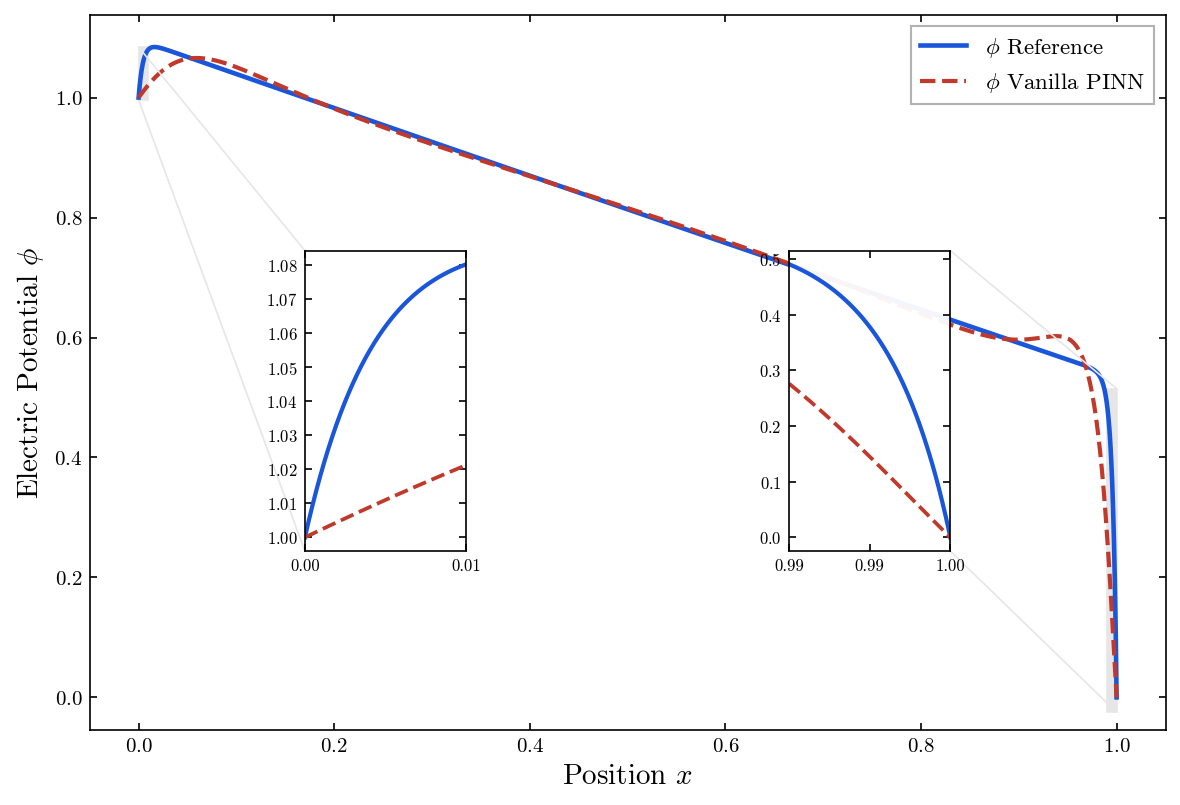

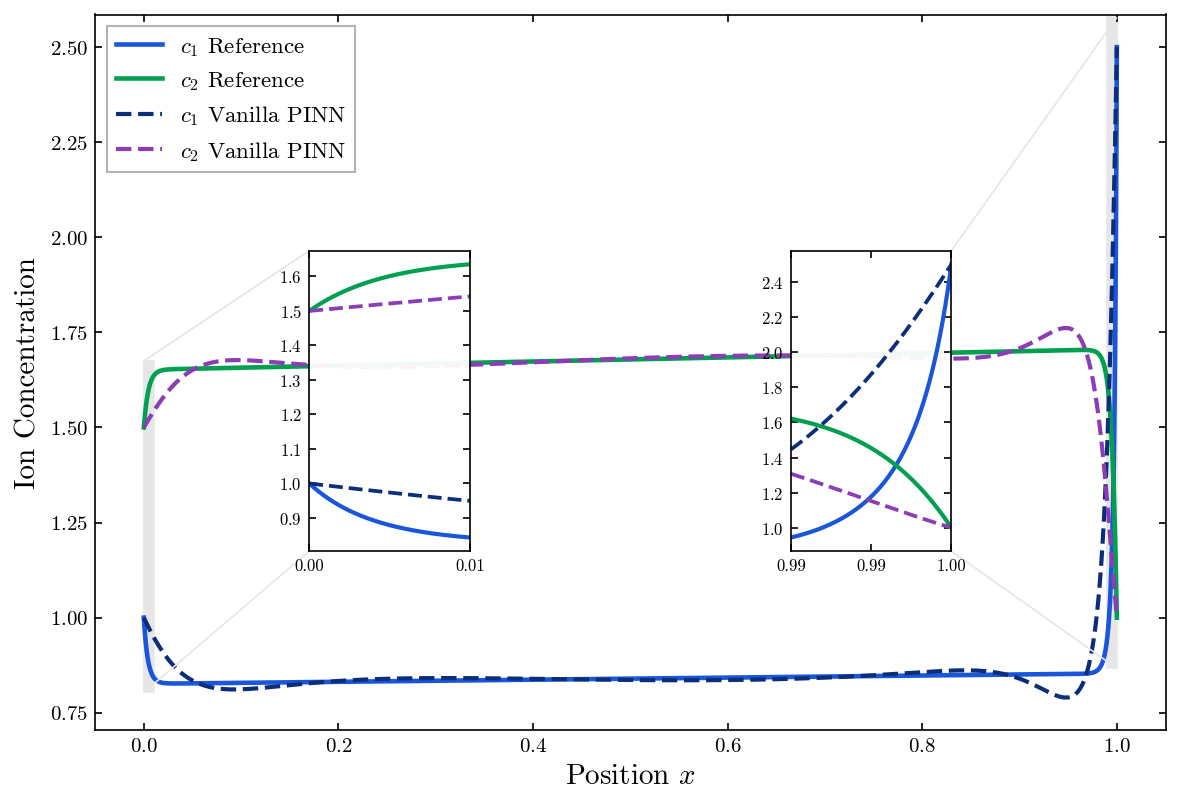

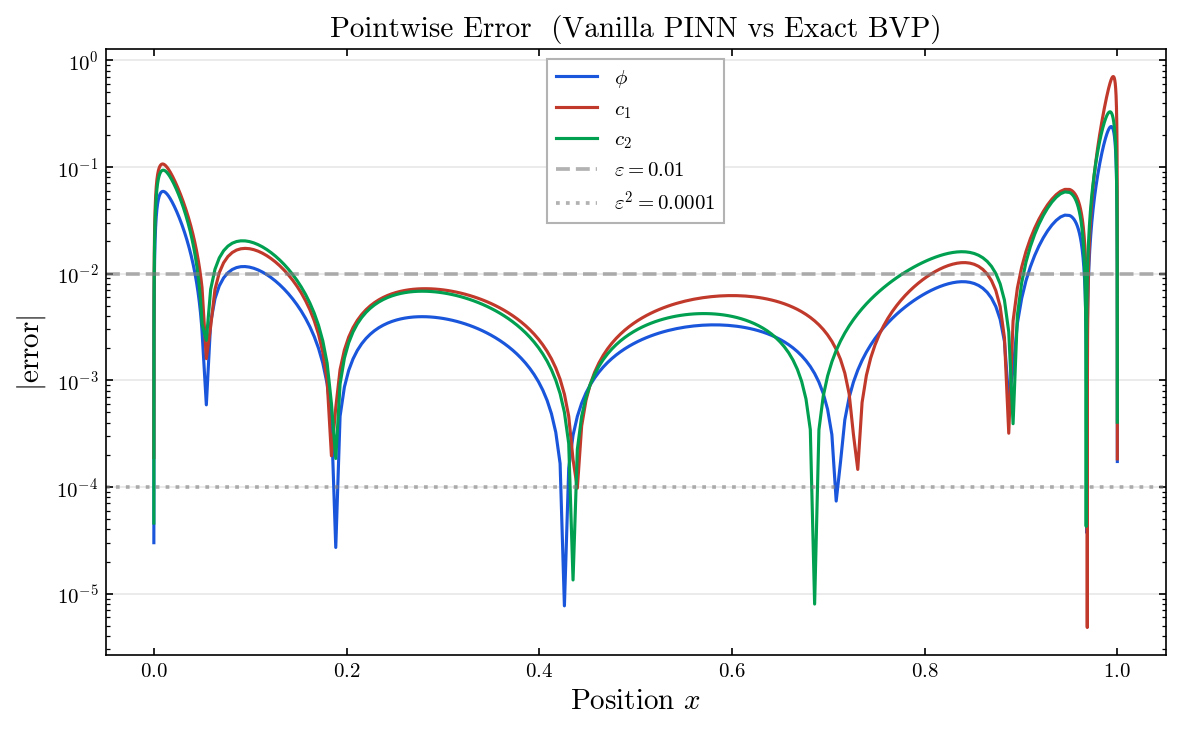

In [11]:
figs = plot_with_inset(x_eval, phi_nn, c1_nn, c2_nn,
                       phi_ex, c1_ex, c2_ex, eps, 'Vanilla PINN')

## 11. 五次独立实验 (固定随机种子)


# ============================================================
#  五次独立实验 (固定随机种子, 报告 mean ± std)
# ============================================================
import copy, time

SEEDS = [0, 1, 2, 3, 4]          # 固定随机种子, 保证可复现
N_RUNS = len(SEEDS)

print('求解精确参考解 ...')
sol_exact = compute_exact_reference(eps, V, L1, L2, R1, R2)
grids = create_evaluation_grid(eps)
x_eval = grids['x']
y_ex = sol_exact.sol(x_eval)
phi_ex, c1_ex, c2_ex = y_ex[0], y_ex[2], y_ex[3]
J1_ex, J2_ex = y_ex[4, 0], y_ex[5, 0]
print(f'精确解通量: J1={J1_ex:.6f}, J2={J2_ex:.6f}, I=2J1-J2={2*J1_ex-J2_ex:.6f}')

all_metrics, all_times = [], []

for run in range(N_RUNS):
    torch.manual_seed(SEEDS[run])
    np.random.seed(SEEDS[run])
    print(f'\n{"="*50}')
    print(f'  Run {run+1}/{N_RUNS}   (seed = {SEEDS[run]})')
    print(f'{"="*50}')
    t0 = time.time()

    model_i = PINN_PNP(layers=[1, 96, 96, 96, 96, 96, 3]).to(DEVICE)
    history_i = train_pinn(model_i, eps, V, L1, L2, R1, R2, DEVICE,
                           epochs=300000, log_interval=30000)
    elapsed = time.time() - t0
    all_times.append(elapsed)

    x_t = torch.tensor(x_eval.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    model_i.eval()
    with torch.no_grad():
        c1_t, c2_t, phi_t = model_i(x_t)
    phi_nn = phi_t.cpu().numpy().flatten()
    c1_nn = c1_t.cpu().numpy().flatten()
    c2_nn = c2_t.cpu().numpy().flatten()
    dphi_dx = np.gradient(phi_nn, x_eval)
    J1_nn = np.median(-(np.gradient(c1_nn, x_eval) + 2.0*c1_nn*dphi_dx))
    J2_nn = np.median(-(np.gradient(c2_nn, x_eval) - c2_nn*dphi_dx))

    m = compute_unified_metrics(
        phi_nn, c1_nn, c2_nn, J1_nn, J2_nn,
        phi_ex, c1_ex, c2_ex, J1_ex, J2_ex, grids)
    all_metrics.append(m)
    print(f'  用时 {elapsed:.1f}s  |  全局相对L²(φ)={m["phi"]["global_rel_L2"]:.4e}')

print(f'\n全部 {N_RUNS} 次实验完成!')

metric_keys = ['global_rel_L2', 'global_Linf', 'inner_rel_L2',
               'inner_Linf', 'junction_err']
metric_labels = ['① 全局相对 L²', '② 全局 L∞', '③ 内区域相对 L²',
                 '④ 内区域 L∞', '⑤ 交界点误差']
var_names = ['phi', 'c1', 'c2']

print(f'\n{"="*80}')
print(f'  Vanilla PINN  {N_RUNS} 次随机实验统计  (Setting B, 2:-1, ε = {eps})')
print(f'{"="*80}')
print(f'{"指标":<22s} | {"phi (mean±std)":>24s} | {"c1 (mean±std)":>24s} | {"c2 (mean±std)":>24s}')
print(f'{"-"*22}-+-{"-"*24}-+-{"-"*24}-+-{"-"*24}')
for mk, ml in zip(metric_keys, metric_labels):
    row = []
    for v in var_names:
        vals = np.array([m[v][mk] for m in all_metrics])
        row.append(f'{vals.mean():.4e} ± {vals.std():.4e}')
    print(f'{ml:<22s} | {row[0]:>24s} | {row[1]:>24s} | {row[2]:>24s}')
print(f'{"-"*22}-+-{"-"*24}-+-{"-"*24}-+-{"-"*24}')
print(f'  训练用时: {np.mean(all_times):.1f} ± {np.std(all_times):.1f} s')